In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras import layers, models, Input
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('dataset_completo.csv')
except Exception as e:
    print(f"Ocurrió un error al cargar el DataFrame: {e}")
    df = pd.DataFrame()

In [3]:
# Randomizacion

random_state = 42

# Funcion para ver la clasificiacion de las muestras tomadas
def extraer_pwm(grabacion_id_str):
    try:
        return int(grabacion_id_str.split('pwm')[1].split('_')[0])
    except Exception:
        return np.nan

# Tabla de referencia: una fila por grabación, con etiqueta y pwm asociados
grabaciones_info = df.groupby('grabacion_id')['etiqueta'].first().reset_index()
grabaciones_info['pwm'] = grabaciones_info['grabacion_id'].apply(extraer_pwm)
grabaciones_info['estrato'] = grabaciones_info['etiqueta'] + '_' + grabaciones_info['pwm'].astype(str)

print(f"Total de grabaciones únicas: {len(grabaciones_info)}")
print(grabaciones_info['estrato'].value_counts().sort_index())


Total de grabaciones únicas: 80
estrato
CD_100    10
CD_125    10
CD_150    10
CD_175    10
CN_100     5
CN_125     5
CN_150     5
CN_175     5
SC_100     5
SC_125     5
SC_150     5
SC_175     5
Name: count, dtype: int64


In [4]:
# Se separan los datos en train y test, por muestra.

# Se separa al nivel de grabacion_id (no de muestra_id ni de filas), y se estratifica por la combinación etiqueta+pwm, para garantizar que las 4 velocidades queden representadas en train y 
# test dentro de cada etiqueta. Con solo 5 grabaciones por estrato (20 estratos en total), test_size=0.2 deja exactamente 1 grabación de cada estrato en test y 4 en train.

train_grab, test_grab = train_test_split(
    grabaciones_info['grabacion_id'],
    test_size=0.2,
    stratify=grabaciones_info['estrato'],
    random_state=random_state
)

# Segundo split: separar validación del train (el test queda intacto, reservado para una sola evaluación final, no para elegir hiperparámetros)
info_train = grabaciones_info[grabaciones_info['grabacion_id'].isin(train_grab)]

train_final_grab, val_grab = train_test_split(
    info_train['grabacion_id'],
    test_size=0.2,
    stratify=info_train['estrato'],
    random_state=random_state
)

print(f"train_final: {len(train_final_grab)} | val: {len(val_grab)} | test: {len(test_grab)}")

df_train = df[df['grabacion_id'].isin(train_final_grab)].reset_index(drop=True)
df_val = df[df['grabacion_id'].isin(val_grab)].reset_index(drop=True)
df_test = df[df['grabacion_id'].isin(test_grab)].reset_index(drop=True)

print(f"\nGrabaciones en train: {len(train_grab)}  |  filas: {len(df_train)}")
print(f"Grabaciones en test:  {len(test_grab)}  |  filas: {len(df_test)}")

# Verificacion: distribución de etiquetas y pwm en train/test
for nombre, subset in [('TRAIN', df_train), ('TEST', df_test)]:
    info = subset.groupby('grabacion_id')['etiqueta'].first().reset_index()
    info['pwm'] = info['grabacion_id'].apply(extraer_pwm)
    print(f"\n--- {nombre} ---")
    print(pd.crosstab(info['etiqueta'], info['pwm']))

train_final: 51 | val: 13 | test: 16

Grabaciones en train: 64  |  filas: 182714
Grabaciones en test:  16  |  filas: 56724

--- TRAIN ---
pwm       100  125  150  175
etiqueta                    
CD          7    7    6    7
CN          3    3    3    3
SC          3    3    3    3

--- TEST ---
pwm       100  125  150  175
etiqueta                    
CD          2    2    2    2
CN          1    1    1    1
SC          1    1    1    1


In [5]:
# Normalizacion (calculada solo con trainset)

# Se normalizan ax, ay, az (la señal cruda, ya que el input al modelo será la serie temporal directa). La etiqueta NO se normaliza es categórica, se codifica por separado más adelante.
#
# Las estadísticas (media, desviación) se calculan solo con df_train, y se aplican igual a df_val y df_test, para no filtrar información de esos conjuntos hacia la normalización del trainset.
#
# Se usa z-score (no min-max) porque ax/ay alcanzan valores cercanosal límite de saturación del MPU-6050 (~±32768 en escala raw de 16 bits).

columnas_senal = ['ax', 'ay', 'az']

media_train = df_train[columnas_senal].mean()
std_train = df_train[columnas_senal].std()

print("\nMedia (train):")
print(media_train)
print("\nDesviación estándar (train):")
print(std_train)

df_train_norm = df_train.copy()
df_val_norm = df_val.copy()
df_test_norm = df_test.copy()

df_train_norm[columnas_senal] = (df_train[columnas_senal] - media_train) / std_train
df_val_norm[columnas_senal] = (df_val[columnas_senal] - media_train) / std_train
df_test_norm[columnas_senal] = (df_test[columnas_senal] - media_train) / std_train

print("\nVerificación post-normalización (train, debe ser ~0 media, ~1 std):")
print(df_train_norm[columnas_senal].agg(['mean', 'std']))
print("\nVerificación post-normalización (val, NO necesariamente ~0/~1, es esperado):")
print(df_val_norm[columnas_senal].agg(['mean', 'std']))
print("\nVerificación post-normalización (test, NO necesariamente ~0/~1, es esperado):")
print(df_test_norm[columnas_senal].agg(['mean', 'std']))


Media (train):
ax      488.905393
ay     -287.591389
az    10109.623767
dtype: float64

Desviación estándar (train):
ax    3366.027126
ay    2369.263293
az    1908.481655
dtype: float64

Verificación post-normalización (train, debe ser ~0 media, ~1 std):
                ax            ay            az
mean  9.955392e-18 -1.431088e-17 -3.409722e-16
std   1.000000e+00  1.000000e+00  1.000000e+00

Verificación post-normalización (val, NO necesariamente ~0/~1, es esperado):
            ax        ay        az
mean  0.022631  0.006132 -0.051053
std   1.195457  1.101658  1.374543

Verificación post-normalización (test, NO necesariamente ~0/~1, es esperado):
            ax        ay        az
mean  0.013711  0.028007 -0.019403
std   1.120573  0.957100  1.396682


In [6]:
# Resampleo a longitud fija (serie temporal directa)

# Cada ventana (grabacion_id + muestra_id) tiene un número de muestras variable (720 a 962, medido sobre el dataset real), por dos motivos:
#   1) diferencias reales de duración entre grabaciones
#   2) eliminación de outliers puntuales en MATLAB (isoutlier), que no interpola los huecos que deja, así que el espaciado en el tiempo dejó de ser uniforme dentro de cada ventana.
#
# Para un modelo que recibe la serie temporal directa, se necesita una longitud fija por muestra. Se eligió N_PUNTOS=900 (cercano a la mediana real de ~899) para no descartar resolución 
# temporal de la mayoría de ventanas, ni inventar demasiados puntos nuevos en las más cortas.
#
# Se interpola usando tiempo_ms REAL como eje x (no el índice de fila), precisamente porque el espaciado ya no es uniforme tras la limpieza de outliers, por lo queinterpolar por índice 
# comprimiría el tiempo alrededor de cada hueco dejado por un outlier eliminado.

N_PUNTOS = 900

def resamplear_ventana(grupo, columnas, n_puntos):
    """Interpola una ventana (grupo de filas con mismo grabacion_id+muestra_id)
    a n_puntos uniformemente espaciados en el tiempo real de esa ventana."""
    grupo = grupo.sort_values('tiempo_ms')
    t_original = grupo['tiempo_ms'].values
    t_nuevo = np.linspace(t_original[0], t_original[-1], n_puntos)

    salida = {'tiempo_ms': t_nuevo}
    for col in columnas:
        salida[col] = np.interp(t_nuevo, t_original, grupo[col].values)
    return pd.DataFrame(salida)

def resamplear_dataset(df_norm, n_puntos):
    resultados = []
    for (grab_id, muestra_id), grupo in df_norm.groupby(['grabacion_id', 'muestra_id']):
        ventana_resampleada = resamplear_ventana(grupo, columnas_senal, n_puntos)
        ventana_resampleada['etiqueta'] = grupo['etiqueta'].iloc[0]
        ventana_resampleada['muestra_id'] = muestra_id
        ventana_resampleada['grabacion_id'] = grab_id
        resultados.append(ventana_resampleada)
    return pd.concat(resultados, ignore_index=True)

print(f"\nResampleando train, validación y test a {N_PUNTOS} puntos por ventana...")
df_train_resampled = resamplear_dataset(df_train_norm, N_PUNTOS)
df_val_resampled = resamplear_dataset(df_val_norm, N_PUNTOS)      # <- esta es la línea nueva
df_test_resampled = resamplear_dataset(df_test_norm, N_PUNTOS)

print(f"Train: {len(df_train_resampled)} filas ({len(df_train_resampled) // N_PUNTOS} ventanas)")
print(f"Val:   {len(df_val_resampled)} filas ({len(df_val_resampled) // N_PUNTOS} ventanas)")
print(f"Test:  {len(df_test_resampled)} filas ({len(df_test_resampled) // N_PUNTOS} ventanas)")

conteo_check_train = df_train_resampled.groupby(['grabacion_id', 'muestra_id']).size()
conteo_check_val = df_val_resampled.groupby(['grabacion_id', 'muestra_id']).size()
conteo_check_test = df_test_resampled.groupby(['grabacion_id', 'muestra_id']).size()
assert (conteo_check_train == N_PUNTOS).all(), "Alguna ventana de train no quedó en N_PUNTOS"
assert (conteo_check_val == N_PUNTOS).all(), "Alguna ventana de val no quedó en N_PUNTOS"
assert (conteo_check_test == N_PUNTOS).all(), "Alguna ventana de test no quedó en N_PUNTOS"
print("Verificación OK: todas las ventanas tienen exactamente N_PUNTOS muestras.")


Resampleando train, validación y test a 900 puntos por ventana...
Train: 183600 filas (204 ventanas)
Val:   46800 filas (52 ventanas)
Test:  57600 filas (64 ventanas)
Verificación OK: todas las ventanas tienen exactamente N_PUNTOS muestras.


In [7]:
# Construccion de los arrays para el modelo (3 ejes juntos)

# Cada ventana se convierte en un array de forma (N_PUNTOS, 3). En cada uno de los 900 instantes, el modelo ve ax, ay, az simultáneamente.
# Por eso x_train/x_test terminan con forma (n_ventanas, 900, 3).

def construir_arrays(df_resampled, columnas, n_puntos):
    x_list = []
    y_list = []
    # sort=True (default) en groupby garantiza orden consistente y
    # reproducible entre llamadas, aunque aquí no se compara contra
    # otro orden externo, así que no es estrictamente necesario, solo
    # buena práctica para depuración reproducible.
    for (grab_id, muestra_id), grupo in df_resampled.groupby(['grabacion_id', 'muestra_id']):
        assert len(grupo) == n_puntos, f"Ventana {grab_id}-{muestra_id} no tiene {n_puntos} puntos"
        x_list.append(grupo[columnas].values)  # forma (n_puntos, len(columnas))
        y_list.append(grupo['etiqueta'].iloc[0])
    x_array = np.stack(x_list)  # forma (n_ventanas, n_puntos, len(columnas))
    y_array = np.array(y_list)
    return x_array, y_array

x_train, y_train_labels = construir_arrays(df_train_resampled, columnas_senal, N_PUNTOS)
x_val, y_val_labels = construir_arrays(df_val_resampled, columnas_senal, N_PUNTOS)      # <- nueva
x_test, y_test_labels = construir_arrays(df_test_resampled, columnas_senal, N_PUNTOS)

print(f"\nx_train: {x_train.shape}")
print(f"x_val:   {x_val.shape}")                                                        # <- nueva
print(f"x_test:  {x_test.shape}")


x_train: (204, 900, 3)
x_val:   (52, 900, 3)
x_test:  (64, 900, 3)


In [8]:
# Codificacion de la etiqueta 

# La salida es categórica: CD/CN/SC. Se usa one-hot encoding + capa de salida softmax + loss categorical_crossentropy.
#
# El encoder se ajusta (fit) SOLO con las clases vistas en train, igual que la normalización. Las 3 clases (CD, CN, SC) están garantizadas en ambos conjuntos por la estratificación
# del split, así que no debería haber clases "nuevas" en test.

from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

label_encoder = LabelEncoder()
label_encoder.fit(y_train_labels)

print(f"\nClases detectadas (orden del encoder): {label_encoder.classes_}")

y_train_int = label_encoder.transform(y_train_labels)
y_val_int = label_encoder.transform(y_val_labels)      # <- nueva
y_test_int = label_encoder.transform(y_test_labels)

n_clases = len(label_encoder.classes_)
y_train = to_categorical(y_train_int, num_classes=n_clases)
y_val = to_categorical(y_val_int, num_classes=n_clases)      # <- nueva
y_test = to_categorical(y_test_int, num_classes=n_clases)

print(f"y_train: {y_train.shape}  (one-hot, {n_clases} clases)")
print(f"y_val:   {y_val.shape}")                              # <- nueva
print(f"y_test:  {y_test.shape}")


Clases detectadas (orden del encoder): ['CD' 'CN' 'SC']
y_train: (204, 3)  (one-hot, 3 clases)
y_val:   (52, 3)
y_test:  (64, 3)


Total de configuraciones a probar: 36
Entrenando 1/36: {'n_conv': 1, 'n_filtros': 8, 'kernel_size': 5, 'learning_rate': 0.001}
Epoch 1/100
13/13 - 1s - 51ms/step - accuracy: 0.2353 - loss: 1.0475 - val_accuracy: 0.3077 - val_loss: 1.0362
Epoch 2/100
13/13 - 0s - 5ms/step - accuracy: 0.2598 - loss: 1.0204 - val_accuracy: 0.3077 - val_loss: 1.0150
Epoch 3/100
13/13 - 0s - 5ms/step - accuracy: 0.3284 - loss: 0.9967 - val_accuracy: 0.3846 - val_loss: 0.9954
Epoch 4/100
13/13 - 0s - 5ms/step - accuracy: 0.4216 - loss: 0.9749 - val_accuracy: 0.4423 - val_loss: 0.9764
Epoch 5/100
13/13 - 0s - 5ms/step - accuracy: 0.5490 - loss: 0.9542 - val_accuracy: 0.5577 - val_loss: 0.9575
Epoch 6/100
13/13 - 0s - 5ms/step - accuracy: 0.6373 - loss: 0.9344 - val_accuracy: 0.6538 - val_loss: 0.9387
Epoch 7/100
13/13 - 0s - 5ms/step - accuracy: 0.7304 - loss: 0.9151 - val_accuracy: 0.6731 - val_loss: 0.9197
Epoch 8/100
13/13 - 0s - 5ms/step - accuracy: 0.7598 - loss: 0.8962 - val_accuracy: 0.6923 - val_loss:

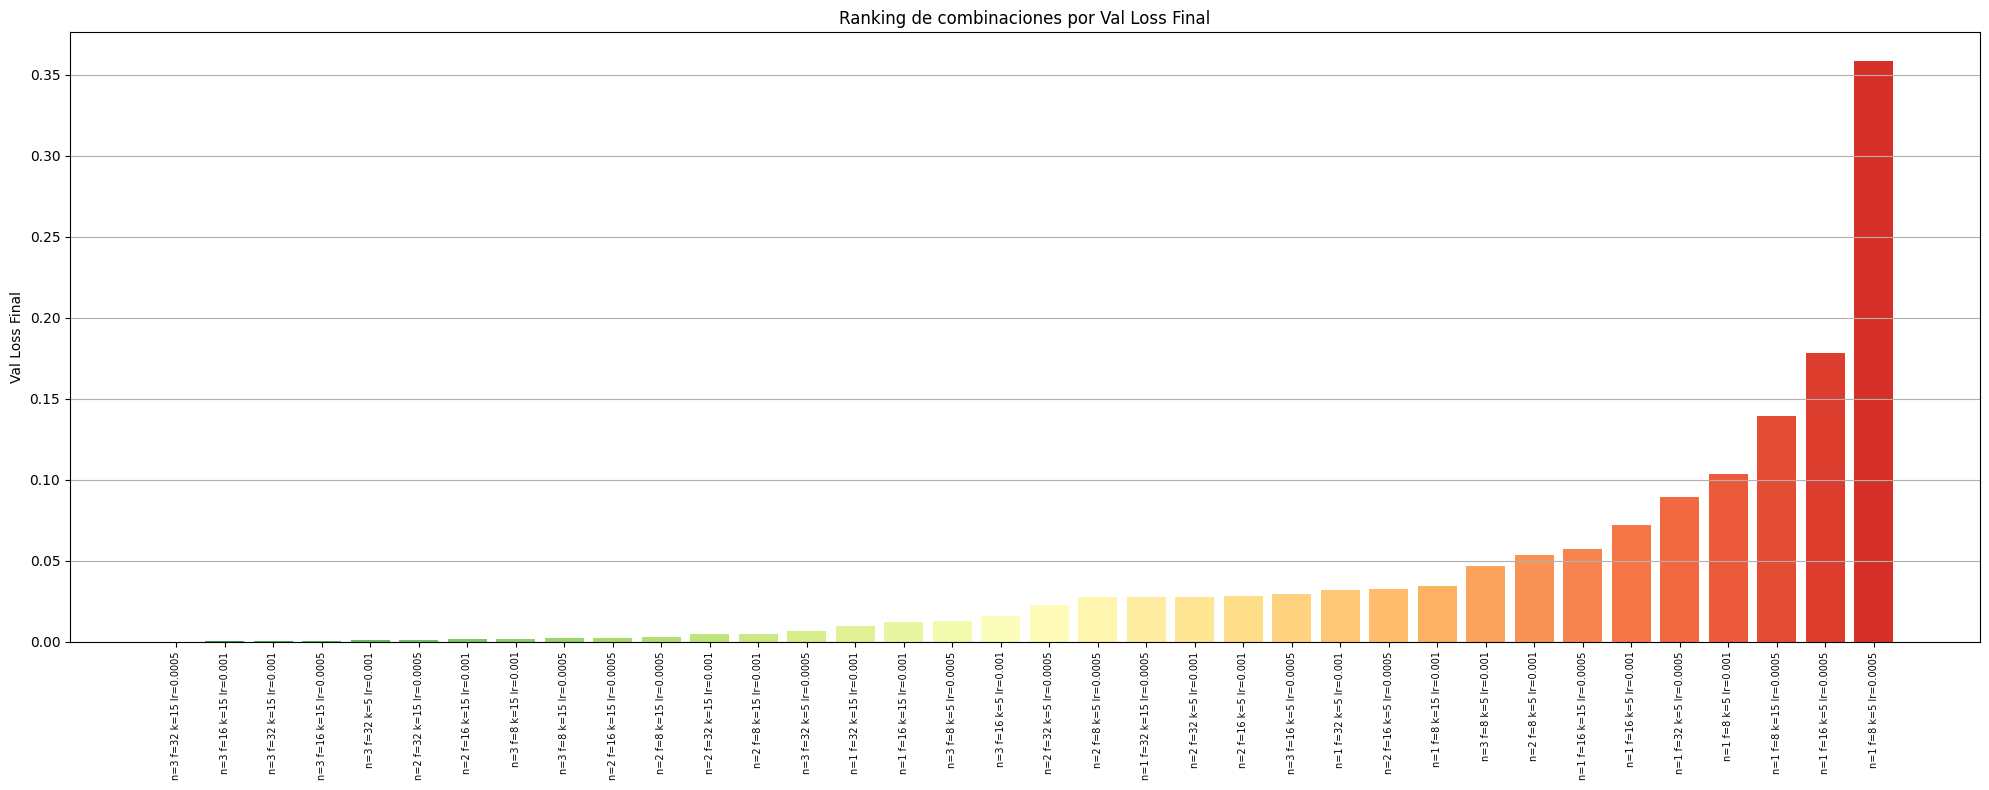

In [9]:
# Funcion de entrenamiento 
#   - Entrada secuencial (900, 3)
#   - Capas Conv1D (con pooling)
#   - Salida softmax de n_clases
#   - Loss categorical_crossentropy
#
# n_filtros: número de filtros en cada capa convolucional (constante entre capas aquí, por simplicidad)
# kernel_size: tamaño de la ventana temporal que ve cada filtro
# n_conv: número de capas Conv1D+Pooling apiladas


# Se hace la funcion para empezar el entrenamiento del modelo 
def entrenar_modelo(n_conv, n_filtros, kernel_size, learning_rate,
                     x_train_in, y_train_in, x_test_in, y_test_in,
                     epochs, batch_size, seed=42, patience=10):

    tf.random.set_seed(seed)

    network = models.Sequential()
    network.add(Input(shape=(N_PUNTOS, len(columnas_senal))))

    for i in range(n_conv):
        network.add(layers.Conv1D(filters=n_filtros, kernel_size=kernel_size,
                                   activation="relu", padding="same"))
        network.add(layers.MaxPooling1D(pool_size=2))

    network.add(layers.GlobalAveragePooling1D())
    network.add(layers.Dense(units=n_clases, activation="softmax"))

    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    history = network.fit(
        x_train_in, y_train_in,
        validation_data=(x_test_in, y_test_in),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stop],
        verbose=2
    )

    return history, network

#Se hace un grid de todas las configuraciones posibles

configuraciones = []
for n_conv in [1, 2, 3]:
    for n_filtros in [8, 16, 32]:
        for kernel_size in [5, 15]:
            for learning_rate in [0.001, 0.0005]:
                configuraciones.append({
                    'n_conv': n_conv, 'n_filtros': n_filtros,
                    'kernel_size': kernel_size, 'learning_rate': learning_rate
                })

print(f"Total de configuraciones a probar: {len(configuraciones)}")

modelos_comparacion = []
for idx, config in enumerate(configuraciones):
    print(f"Entrenando {idx+1}/{len(configuraciones)}: {config}")
    history, modelo = entrenar_modelo(
        **config,
        x_train_in=x_train, y_train_in=y_train,
        x_test_in=x_val, y_test_in=y_val,
        epochs=100, batch_size=16, seed=42, patience=10
    )
    modelos_comparacion.append({
        'config': config, 'history': history, 'modelo': modelo,
        'val_accuracy_final': history.history['val_accuracy'][-1],
        'val_loss_final': history.history['val_loss'][-1],
        'epocas_reales': len(history.history['loss'])
    })

ranking = sorted(modelos_comparacion, key=lambda x: x['val_loss_final'])
print("\n=== TOP 10 (por val_loss) ===")
for i, r in enumerate(ranking[:10], 1):
    c = r['config']
    print(f"{i}. n_conv={c['n_conv']}, filtros={c['n_filtros']}, "
          f"kernel={c['kernel_size']}, lr={c['learning_rate']} -> "
          f"val_loss={r['val_loss_final']:.4f}, val_acc={r['val_accuracy_final']:.4f}, "
          f"épocas reales={r['epocas_reales']}")

# Grafica de ranking

labels = [f"n={r['config']['n_conv']} f={r['config']['n_filtros']} "
          f"k={r['config']['kernel_size']} lr={r['config']['learning_rate']}"
          for r in ranking]
val_losses = [r['val_loss_final'] for r in ranking]

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(ranking)))

plt.figure(figsize=(20, 8))
plt.bar(labels, val_losses, color=colors)
plt.title("Ranking de combinaciones por Val Loss Final")
plt.ylabel("Val Loss Final")
plt.xticks(rotation=90, fontsize=7)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

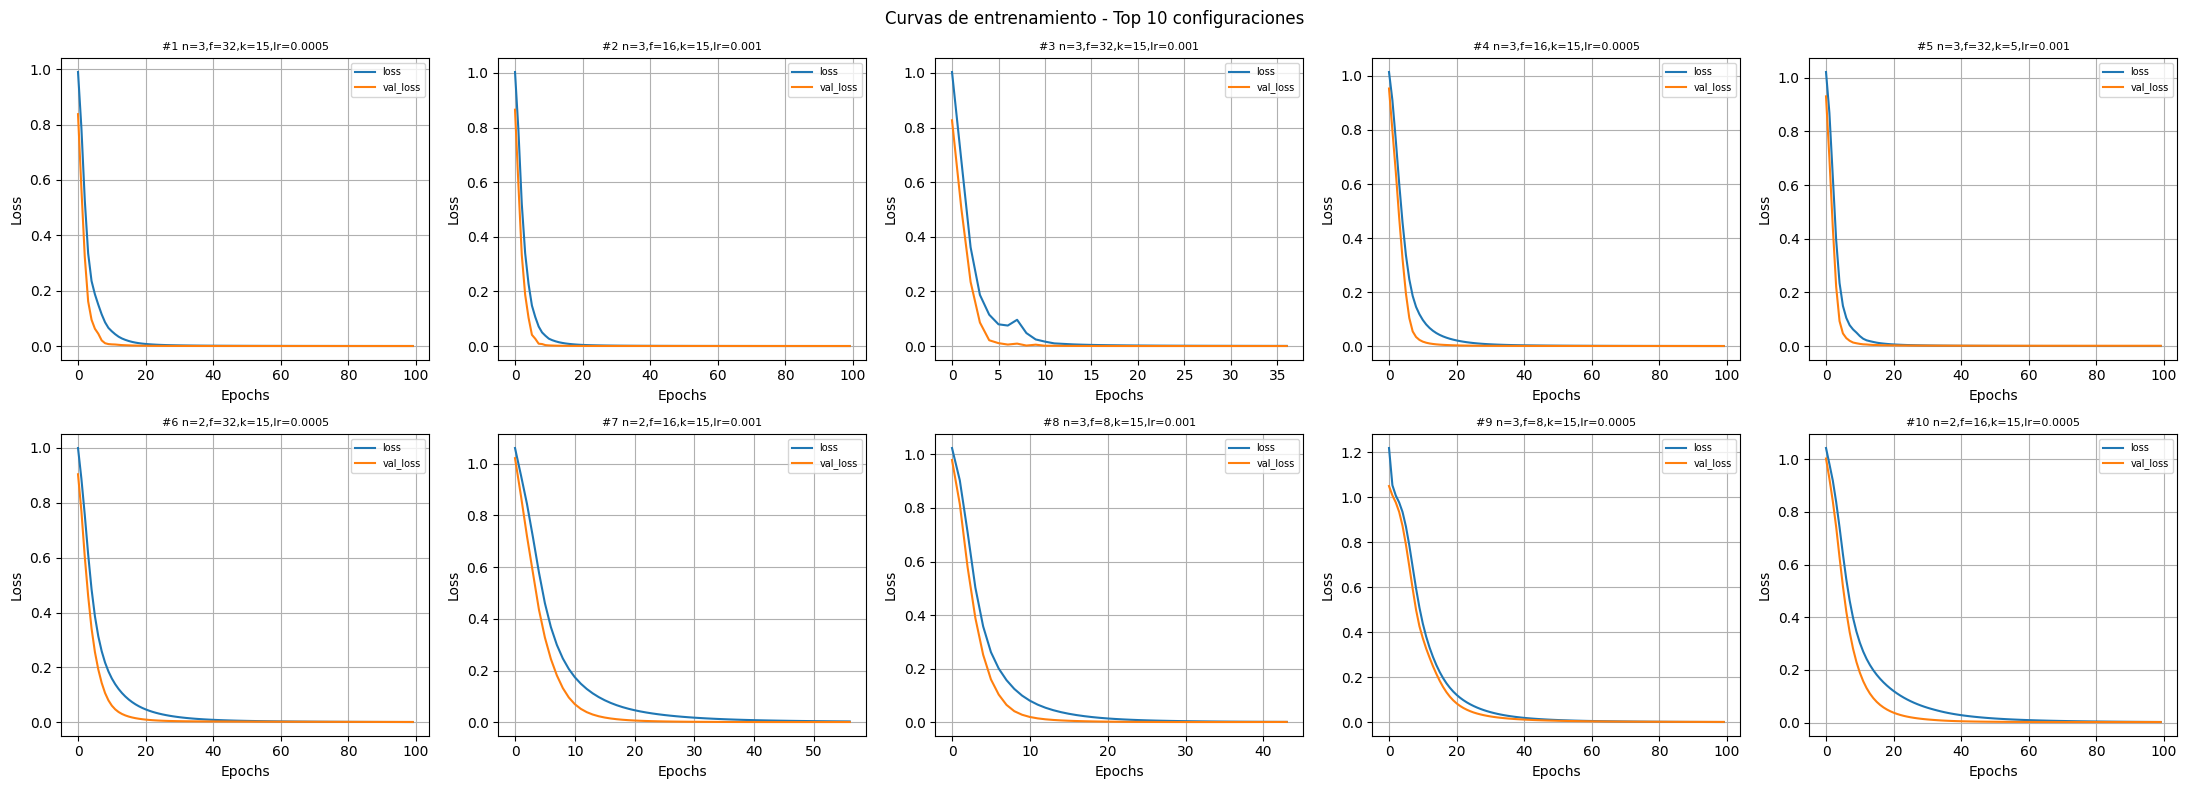

In [10]:
# Curvas de entrenamientoO - Top 10 

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for idx, entry in enumerate(ranking[:10]):
    config = entry['config']
    hist = entry['history'].history
    label = (f"#{idx+1} n={config['n_conv']},f={config['n_filtros']},"
             f"k={config['kernel_size']},lr={config['learning_rate']}")
    axes[idx].plot(hist['loss'], label='loss')
    axes[idx].plot(hist['val_loss'], label='val_loss')
    axes[idx].set_title(label, fontsize=8)
    axes[idx].set_xlabel("Epochs")
    axes[idx].set_ylabel("Loss")
    axes[idx].legend(fontsize=7)
    axes[idx].grid()

plt.suptitle("Curvas de entrenamiento - Top 10 configuraciones")
plt.tight_layout()
plt.show()

In [12]:
# Verificacion del top 10 con diferentes semillas (3 diferentes)
# ============================================================
# El ranking anterior usó una sola semilla (42), lo cual no permite distinguir con confianza mejoras reales de ruido de inicialización.
# Aquí se reentrenan las 10 mejores configuraciones con 3 semillas distintas cada una, y se reporta val_loss/val_acc como media ± std.

semillas = [42, 123, 7]
resultados_top3 = []

for i, entry in enumerate(ranking[:10]):
    config = entry['config']
    val_losses_semilla = []
    val_accs_semilla = []

    for s in semillas:
        history, modelo = entrenar_modelo(
            **config,
            x_train_in=x_train, y_train_in=y_train,
            x_test_in=x_val, y_test_in=y_val,
            epochs=100, batch_size=16, seed=s, patience=10
        )
        val_losses_semilla.append(history.history['val_loss'][-1])
        val_accs_semilla.append(history.history['val_accuracy'][-1])

    resultados_top3.append({
        'config': config,
        'val_loss_mean': np.mean(val_losses_semilla),
        'val_loss_std': np.std(val_losses_semilla),
        'val_acc_mean': np.mean(val_accs_semilla),
        'val_acc_std': np.std(val_accs_semilla),
    })

    print(f"\nTop {i+1}: {config}")
    print(f"  val_loss por semilla: {val_losses_semilla}")
    print(f"  val_loss = {np.mean(val_losses_semilla):.4f} +/- {np.std(val_losses_semilla):.4f}")
    print(f"  val_acc  = {np.mean(val_accs_semilla):.4f} +/- {np.std(val_accs_semilla):.4f}")

print("\n=== RESUMEN TOP 10 (ordenado por val_loss promedio) ===")
for r in sorted(resultados_top3, key=lambda x: x['val_loss_mean']):
    print(f"{r['config']} -> val_loss={r['val_loss_mean']:.4f}+/-{r['val_loss_std']:.4f}, "
          f"val_acc={r['val_acc_mean']:.4f}+/-{r['val_acc_std']:.4f}")

Epoch 1/100
13/13 - 1s - 61ms/step - accuracy: 0.3333 - loss: 1.0313 - val_accuracy: 0.4231 - val_loss: 0.9463
Epoch 2/100
13/13 - 0s - 9ms/step - accuracy: 0.6765 - loss: 0.8657 - val_accuracy: 0.7115 - val_loss: 0.6754
Epoch 3/100
13/13 - 0s - 9ms/step - accuracy: 0.8725 - loss: 0.5781 - val_accuracy: 0.8269 - val_loss: 0.4077
Epoch 4/100
13/13 - 0s - 9ms/step - accuracy: 0.9118 - loss: 0.3399 - val_accuracy: 0.8846 - val_loss: 0.2465
Epoch 5/100
13/13 - 0s - 10ms/step - accuracy: 0.9314 - loss: 0.2192 - val_accuracy: 0.9231 - val_loss: 0.1599
Epoch 6/100
13/13 - 0s - 9ms/step - accuracy: 0.9510 - loss: 0.1642 - val_accuracy: 1.0000 - val_loss: 0.0510
Epoch 7/100
13/13 - 0s - 10ms/step - accuracy: 0.9657 - loss: 0.1299 - val_accuracy: 1.0000 - val_loss: 0.0218
Epoch 8/100
13/13 - 0s - 9ms/step - accuracy: 0.9755 - loss: 0.0962 - val_accuracy: 1.0000 - val_loss: 0.0150
Epoch 9/100
13/13 - 0s - 10ms/step - accuracy: 0.9853 - loss: 0.0651 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 

In [15]:
# Modelo final y evaluacion con el testset

config_final = {'n_conv': 3, 'n_filtros': 32, 'kernel_size': 15, 'learning_rate': 0.001}

history_final, modelo_final = entrenar_modelo(
    **config_final,
    x_train_in=x_train, y_train_in=y_train,
    x_test_in=x_val, y_test_in=y_val,
    epochs=100, batch_size=16, seed=42, patience=10
)

test_loss, test_acc = modelo_final.evaluate(x_test, y_test, verbose=0)
print(f"\n=== EVALUACIÓN FINAL (test reservado, primera y única vez) ===")
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

from sklearn.metrics import confusion_matrix, classification_report
y_pred = np.argmax(modelo_final.predict(x_test, verbose=0), axis=1)
y_real = np.argmax(y_test, axis=1)

print("\nMatriz de confusión (test):")
print(confusion_matrix(y_real, y_pred))
print("\nReporte de clasificación (test):")
print(classification_report(y_real, y_pred, target_names=label_encoder.classes_))

Epoch 1/100
13/13 - 1s - 61ms/step - accuracy: 0.3873 - loss: 1.0105 - val_accuracy: 0.6923 - val_loss: 0.8814
Epoch 2/100
13/13 - 0s - 9ms/step - accuracy: 0.8578 - loss: 0.6871 - val_accuracy: 0.9423 - val_loss: 0.3319
Epoch 3/100
13/13 - 0s - 9ms/step - accuracy: 0.9314 - loss: 0.2778 - val_accuracy: 1.0000 - val_loss: 0.0735
Epoch 4/100
13/13 - 0s - 9ms/step - accuracy: 0.9559 - loss: 0.1488 - val_accuracy: 1.0000 - val_loss: 0.0241
Epoch 5/100
13/13 - 0s - 9ms/step - accuracy: 0.9755 - loss: 0.0993 - val_accuracy: 1.0000 - val_loss: 0.0077
Epoch 6/100
13/13 - 0s - 9ms/step - accuracy: 0.9706 - loss: 0.0780 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 7/100
13/13 - 0s - 9ms/step - accuracy: 0.9657 - loss: 0.1101 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 8/100
13/13 - 0s - 9ms/step - accuracy: 0.9608 - loss: 0.1043 - val_accuracy: 0.9808 - val_loss: 0.0405
Epoch 9/100
13/13 - 0s - 9ms/step - accuracy: 0.9461 - loss: 0.1258 - val_accuracy: 1.0000 - val_loss: 0.0260
Epoch 10/

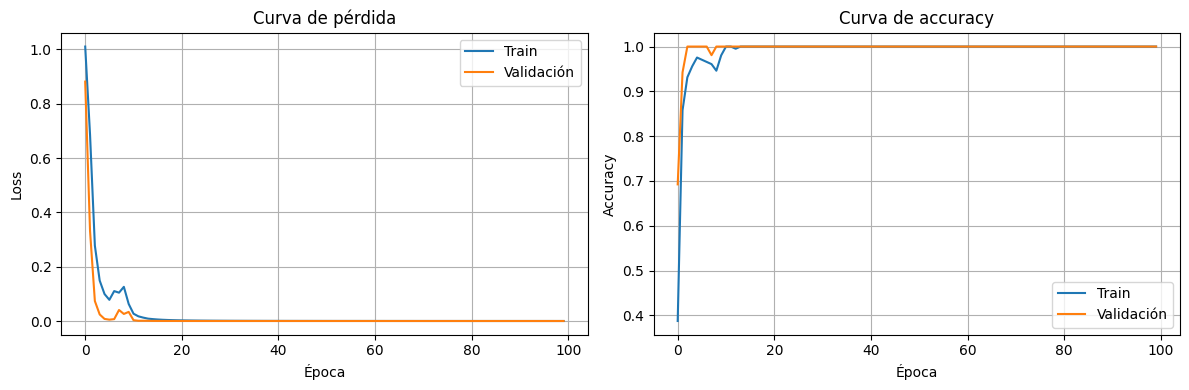

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Pérdida (loss) ---
axes[0].plot(history_final.history['loss'], label='Train')
axes[0].plot(history_final.history['val_loss'], label='Validación')
axes[0].set_title('Curva de pérdida')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# --- Accuracy ---
axes[1].plot(history_final.history['accuracy'], label='Train')
axes[1].plot(history_final.history['val_accuracy'], label='Validación')
axes[1].set_title('Curva de accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('curva_entrenamiento_final.png', dpi=150)
plt.show()

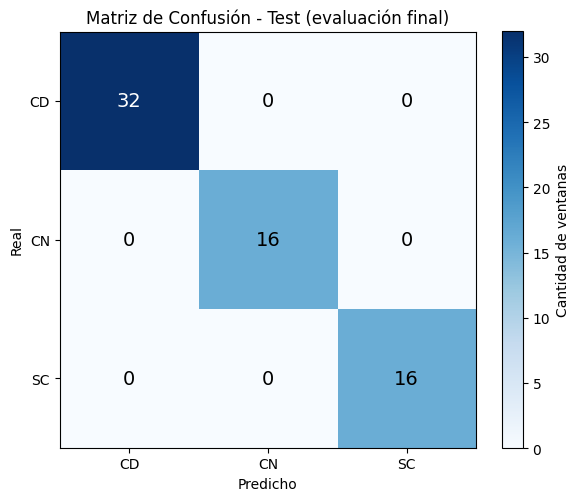

In [18]:
# Visualizacion de la matriz de confusion en un heatmap

cm = confusion_matrix(y_real, y_pred)
clases = label_encoder.classes_

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(clases)))
ax.set_yticks(range(len(clases)))
ax.set_xticklabels(clases)
ax.set_yticklabels(clases)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión - Test (evaluación final)')

# Número dentro de cada celda, con color de texto que se adapta
# al fondo (blanco sobre celdas oscuras, negro sobre claras)
for i in range(len(clases)):
    for j in range(len(clases)):
        valor = cm[i, j]
        color = 'white' if valor > cm.max() / 2 else 'black'
        ax.text(j, i, str(valor), ha='center', va='center', color=color, fontsize=14)

plt.colorbar(im, ax=ax, label='Cantidad de ventanas')
plt.tight_layout()
plt.show()

In [19]:
#Se salva el modelo para poder hacer la prediccion en tiempo real.
modelo_final.save('modelo_final.keras')
np.save('media_train.npy', media_train.values)
np.save('std_train.npy', std_train.values)
np.save('clases.npy', label_encoder.classes_)